# 🏗️ Terrain Vente — Pipeline v4 (Données enrichies)

**Améliorations v4 vs v3 :**
- `kw_facade` : corrélation 0.231 avec log(prix/m²) — nouveau signal fort
- `kw_projet` : corrélation 0.170 avec log(prix) — terrains avec projet = plus grands
- `statut_titre` : TF / Melkiya / non-spécifié (3 catégories vs binaire)
- `log_surface` cubique et interactions surface×zone améliorées
- Descriptions `marrakechrealty` + `milkiya` mieux exploitées

## 0. Imports

In [1]:
import os, sys, json, joblib, warnings, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from datetime import datetime
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath("../../pipeline"))

RAW_PATH   = "../../data/marrakech_immo_vente/terrain_vente.csv"
CLEAN_PATH = "../../data/cleaned_data/vente/terrain_vente_final.csv"
MODEL_PATH = "../../model_training/models/xgb_terrain_vente.pkl"
META_PATH  = "../../model_training/models/xgb_terrain_vente_metadata.json"
print("✅ Imports OK")


/home/nouhayla/Desktop/stage/gateone-deploy/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Imports OK


## 1. Chargement & Cleaning

In [2]:
df = pd.read_csv(RAW_PATH)
print(f"Brut : {df.shape}")

# Terrains uniquement
df = df[df["type_bien"].isin(["Terrain","Vente Terrain"])].copy()
print(f"Terrains : {len(df)}")

# Déduplication sur contenu
df = df.drop_duplicates(subset=["prix_num","surface_num","localisation"]).copy()

# EUR → MAD
EUR_TO_MAD = 10.8
eur_mask = df["prix"].str.contains("EUR", na=False)
df.loc[eur_mask, "prix_num"] = df.loc[eur_mask, "prix_num"] * EUR_TO_MAD

# Filtres
df = df[df["prix_num"].notna() & (df["prix_num"] > 0)].copy()
df = df[df["surface_num"].notna() & (df["surface_num"] >= 50) & (df["surface_num"] <= 500_000)].copy()
df["_ppm2"] = df["prix_num"] / df["surface_num"]
df = df[(df["_ppm2"] >= 50) & (df["_ppm2"] <= 50_000)].copy()
df.drop(columns=["_ppm2"], inplace=True)
df = df[df["prix_num"] >= 100_000].copy()
lp = np.log(df["prix_num"])
df = df[(lp >= lp.quantile(0.01)) & (lp <= lp.quantile(0.99))].copy()

df["pm2"]      = df["prix_num"] / df["surface_num"]
df["log_pm2"]  = np.log(df["pm2"])
df["log_prix"] = np.log(df["prix_num"])

print(f"Après cleaning : {df.shape}")
print(f"Prix médian    : {df['prix_num'].median():,.0f} MAD")
print(f"Prix/m² médian : {df['pm2'].median():,.0f} MAD/m²")
print(f"Surface médiane: {df['surface_num'].median():,.0f} m²")


Brut : (3726, 34)
Terrains : 2389
Après cleaning : (1286, 37)
Prix médian    : 1,600,000 MAD
Prix/m² médian : 829 MAD/m²
Surface médiane: 1,295 m²


## 2. Feature Engineering

**Features textuelles enrichies v4 :**
- `kw_facade` (corr 0.231) — terrains avec façade = constructibilité confirmée
- `kw_projet` (corr 0.170) — terrains avec projet = meilleure localisation
- `statut_titre` — TF / Melkiya / non-spécifié (catégorielle)
- `kw_immeuble` (corr 0.267) — usage immeuble = prix/m² élevé
- `kw_agricole` (corr -0.340) — signal négatif fort

In [3]:
# Texte unifié
df["text_all"] = (
    df["description"].fillna("") + " " +
    df["titre"].fillna("") + " " +
    df["localisation"].fillna("")
).str.lower()

# Keywords v4 (tous les signaux utiles)
kw_dict = {
    "kw_immeuble"    : r"immeuble|r\+[0-9]|rez.de",
    "kw_agricole"    : r"agricole|agri\b|oliveraie|palmier|verger",
    "kw_golf"        : r"golf|amelkis",
    "kw_villa_zone"  : r"zone villa|lotissement villa",
    "kw_resid"       : r"résidentiel|zone résid",
    "kw_facade"      : r"façade|front de",          # nouveau v4
    "kw_projet"      : r"projet|promotion|programme", # nouveau v4
    "kw_constructible":r"constructible|à bâtir|permis",
    "kw_plat"        : r"terrain plat|nivelé|plat\b",
    "kw_urgent"      : r"urgent|à saisir|négociable",
    "kw_viabilise"   : r"viabili|raccord|eau.élect",
    "kw_industriel"  : r"industriel|zone indus",
}
for feat, pattern in kw_dict.items():
    df[feat] = df["text_all"].str.contains(pattern, regex=True, na=False).astype(int)

# Statut titre (catégorielle 3 classes)
df["kw_tf"]   = df["text_all"].str.contains(r"titré|titre foncier|\btf\b", regex=True, na=False).astype(int)
df["kw_melk"] = df["text_all"].str.contains(r"melk|melkia", regex=True, na=False).astype(int)
df["statut_titre"] = "non_specifie"
df.loc[df["kw_tf"]   == 1, "statut_titre"] = "titre_foncier"
df.loc[(df["kw_melk"] == 1) & (df["kw_tf"] == 0), "statut_titre"] = "melkiya"

# Score qualité terrain
df["terrain_quality"] = (
    df["kw_immeuble"]    * 4 +
    df["kw_facade"]      * 3 +
    df["kw_golf"]        * 3 +
    df["kw_villa_zone"]  * 2 +
    df["kw_constructible"]* 2 +
    df["kw_viabilise"]   * 2 +
    df["kw_plat"]        * 1 +
    df["kw_tf"]          * 1 -
    df["kw_agricole"]    * 3 -
    df["kw_industriel"]  * 1
)

# Usage terrain (catégorielle 5 classes)
df["usage_terrain"] = "autre"
df.loc[df["kw_immeuble"]  == 1, "usage_terrain"] = "immeuble"
df.loc[df["kw_agricole"]  == 1, "usage_terrain"] = "agricole"
df.loc[df["kw_golf"]      == 1, "usage_terrain"] = "golf"
df.loc[df["kw_industriel"]== 1, "usage_terrain"] = "industriel"

# Quartier clean
top_q = df["quartier"].value_counts().index[:10]
df["quartier_clean"] = df["quartier"].apply(lambda x: x if x in top_q else "Autre")

# Zone fine (localisation fine)
df["zone_clean"] = (
    df["localisation"].str.split(",").str[0].str.strip().str.lower()
    .str.replace(r"[^a-zàâäéèêëîïôùûü '\-]", "", regex=True)
    .str.strip()
)
counts = df["zone_clean"].value_counts()
df["zone_clean"] = df["zone_clean"].apply(lambda x: x if x in counts[counts >= 6].index else "autre_zone")
print(f"Zones retenues : {df['zone_clean'].nunique()}")

# Source clean
df["source_clean"] = df["source"].fillna("inconnu").str.lower().str.strip()

# Features numériques (log-transformées)
df["log_surface"]    = np.log(df["surface_num"])
df["log_surface_sq"] = df["log_surface"] ** 2
df["log_surface_cb"] = df["log_surface"] ** 3

# Tranche surface
df["surface_cat"] = pd.cut(
    df["surface_num"],
    bins=[0, 300, 1000, 5000, 20000, 100000, 999999],
    labels=["micro","petit","moyen","grand","tres_grand","domaine"]
).astype(str)

print(f"\n✅ Shape finale : {df.shape}")
print(f"\nusage_terrain distribution :")
print(df["usage_terrain"].value_counts())
print(f"\nstatut_titre distribution :")
print(df["statut_titre"].value_counts())
print(f"\nterrain_quality stats :")
print(df["terrain_quality"].describe().round(2))


Zones retenues : 38

✅ Shape finale : (1286, 62)

usage_terrain distribution :
usage_terrain
autre         965
agricole      150
golf           80
immeuble       74
industriel     17
Name: count, dtype: int64

statut_titre distribution :
statut_titre
non_specifie     820
titre_foncier    405
melkiya           61
Name: count, dtype: int64

terrain_quality stats :
count    1286.00
mean        1.06
std         2.26
min        -4.00
25%         0.00
50%         0.00
75%         3.00
max        12.00
Name: terrain_quality, dtype: float64


## 3. Corrélations

In [4]:
num_features_check = [
    "log_surface","log_surface_sq","log_surface_cb","terrain_quality",
    "kw_immeuble","kw_agricole","kw_facade","kw_projet","kw_golf",
    "kw_tf","kw_melk","kw_constructible","kw_urgent"
]
print("=== Corrélation → log(prix/m²) ===")
corr_pm2  = df[[c for c in num_features_check if c in df.columns]+["log_pm2"]].corr()["log_pm2"].drop("log_pm2")
print(corr_pm2.sort_values(ascending=False).round(3))

print("\n=== Corrélation → log(prix_total) ===")
corr_prix = df[[c for c in num_features_check if c in df.columns]+["log_prix"]].corr()["log_prix"].drop("log_prix")
print(corr_prix.sort_values(ascending=False).round(3))

print("\n=== Prix/m² médian par usage_terrain ===")
print(df.groupby("usage_terrain")["pm2"].agg(["median","count","std"]).sort_values("median",ascending=False).round(0))

print("\n=== Variance log_pm2 par usage_terrain ===")
print(df.groupby("usage_terrain")["log_pm2"].agg(["mean","std","count"]).sort_values("std").round(3))


=== Corrélation → log(prix/m²) ===
terrain_quality     0.394
kw_immeuble         0.265
kw_facade           0.234
kw_golf             0.083
kw_constructible    0.022
kw_urgent           0.007
kw_tf              -0.065
kw_projet          -0.108
kw_melk            -0.119
kw_agricole        -0.348
log_surface_cb     -0.752
log_surface_sq     -0.784
log_surface        -0.802
Name: log_pm2, dtype: float64

=== Corrélation → log(prix_total) ===
log_surface_cb      0.529
log_surface_sq      0.522
log_surface         0.509
kw_projet           0.173
kw_immeuble         0.099
kw_tf               0.065
kw_golf             0.060
kw_agricole         0.052
terrain_quality     0.050
kw_constructible   -0.000
kw_facade          -0.010
kw_urgent          -0.035
kw_melk            -0.117
Name: log_prix, dtype: float64

=== Prix/m² médian par usage_terrain ===
               median  count     std
usage_terrain                       
immeuble       7673.0     74  9250.0
golf           3929.0     80  3922.0

## 4. Split + Encoding groupby (sans leakage)

In [5]:
NUMERIC_FEATURES_BASE = [
    "log_surface","log_surface_sq","log_surface_cb","surface_num",
    "terrain_quality",
    "kw_immeuble","kw_facade","kw_projet","kw_golf",
    "kw_villa_zone","kw_resid","kw_constructible",
    "kw_plat","kw_urgent","kw_viabilise","kw_industriel",
    "kw_tf","kw_melk",
]
BINARY_FEATURES = [
    "piscine","parking","jardin","securite","vue","neuf",
    "kw_agricole",
]
CATEGORICAL_FEATURES = [
    "quartier_clean","zone_clean","usage_terrain","statut_titre",
    "surface_cat","source_clean",
]
TARGET_LOG = "log_prix"  # Prédire log(prix_total) — meilleur que log(pm²)

all_base = NUMERIC_FEATURES_BASE + BINARY_FEATURES + CATEGORICAL_FEATURES
X_base = df[all_base].copy()
y      = df[TARGET_LOG].copy()

X_train_b, X_test_b, y_train, y_test = train_test_split(
    X_base, y, test_size=0.2, random_state=42
)

# Groupby features calculées sur train uniquement
def add_groupby(X_tr, X_te, df_tr_full):
    tmp = X_tr.copy()
    tmp["pm2"]      = np.exp(y_train) / df_tr_full["surface_num"].values
    tmp["prix_num"] = np.exp(y_train)

    z_pm2_med  = tmp.groupby("zone_clean")["pm2"].median()
    z_pm2_mean = tmp.groupby("zone_clean")["pm2"].mean()
    z_surf_med = tmp.groupby("zone_clean")["surface_num"].apply(
        lambda x: df_tr_full.loc[x.index, "surface_num"].median()
        if len(x) > 0 else np.nan
    )
    q_pm2_med  = tmp.groupby("quartier_clean")["pm2"].median()
    fp2 = tmp["pm2"].median()
    fs  = df_tr_full["surface_num"].median()

    for X in [X_tr, X_te]:
        surf = df.loc[X.index, "surface_num"] if X is X_te else df_tr_full["surface_num"]
        X["q_pm2_median"]    = X["quartier_clean"].map(q_pm2_med).fillna(fp2)
        X["z_pm2_median"]    = X["zone_clean"].map(z_pm2_med).fillna(fp2)
        X["z_pm2_mean"]      = X["zone_clean"].map(z_pm2_mean).fillna(fp2)
        X["prix_estime"]     = surf * X["z_pm2_median"]
        X["log_prix_estime"] = np.log(X["prix_estime"].clip(lower=1))
        X["log_surf_x_pm2"]  = X["log_surface"] * X["z_pm2_median"] / 1e3
        X["surf_rel_zone"]   = surf / X["zone_clean"].map(z_surf_med).fillna(fs)
        X["te_log_pm2_zone"] = X["zone_clean"].map(
            tmp.groupby("zone_clean")["pm2"].apply(lambda x: np.log(x).mean())
        ).fillna(np.log(fp2))
    return X_tr, X_te

df_train_full = df.loc[X_train_b.index].copy()
X_train, X_test = add_groupby(X_train_b.copy(), X_test_b.copy(), df_train_full)

GROUPBY_FEATURES = [
    "q_pm2_median","z_pm2_median","z_pm2_mean",
    "prix_estime","log_prix_estime","log_surf_x_pm2",
    "surf_rel_zone","te_log_pm2_zone",
]
NUMERIC_FEATURES = NUMERIC_FEATURES_BASE + GROUPBY_FEATURES
ALL_FEATURES     = NUMERIC_FEATURES + BINARY_FEATURES + CATEGORICAL_FEATURES

print(f"✅ Split — Train : {len(X_train)} | Test : {len(X_test)}")
print(f"   Features : {len(ALL_FEATURES)} ({len(NUMERIC_FEATURES)} num + {len(BINARY_FEATURES)} bin + {len(CATEGORICAL_FEATURES)} cat)")


✅ Split — Train : 1028 | Test : 258
   Features : 39 (26 num + 7 bin + 6 cat)


## 5. Preprocessor

In [6]:
num_cols = [c for c in NUMERIC_FEATURES if c in X_train.columns]
bin_cols = [c for c in BINARY_FEATURES  if c in X_train.columns]
cat_cols = [c for c in CATEGORICAL_FEATURES if c in X_train.columns]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(),                                              num_cols),
    ("bin", "passthrough",                                                 bin_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),   cat_cols),
], remainder="drop")
preprocessor.fit(X_train[ALL_FEATURES])
print(f"✅ Preprocessor — {len(num_cols)} num | {len(bin_cols)} bin | {len(cat_cols)} cat")


✅ Preprocessor — 26 num | 7 bin | 6 cat


## 6. Optuna — 150 trials

> ⏱️ ~5 minutes

In [7]:
ALL_COLS = ALL_FEATURES

def objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int("n_estimators", 500, 4000),
        learning_rate     = trial.suggest_float("learning_rate", 0.003, 0.08, log=True),
        max_depth         = trial.suggest_int("max_depth", 2, 7),
        max_leaves        = trial.suggest_int("max_leaves", 8, 63),
        subsample         = trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree  = trial.suggest_float("colsample_bytree", 0.4, 1.0),
        colsample_bylevel = trial.suggest_float("colsample_bylevel", 0.4, 1.0),
        min_child_weight  = trial.suggest_int("min_child_weight", 2, 20),
        reg_alpha         = trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        reg_lambda        = trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        gamma             = trial.suggest_float("gamma", 0, 5),
        tree_method       = "hist",
    )
    pipe = Pipeline([("pre", preprocessor),
                     ("model", XGBRegressor(**params, random_state=42, n_jobs=-1))])
    return cross_val_score(
        pipe, X_train[ALL_COLS], y_train, cv=5, scoring="r2", n_jobs=-1
    ).mean()

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=150, show_progress_bar=True)

print(f"\n✅ Meilleur R² CV : {study.best_value:.4f}")
for k, v in study.best_params.items():
    print(f"  {k:25s} : {v}")


Best trial: 143. Best value: 0.613058: 100%|██████████| 150/150 [03:02<00:00,  1.22s/it]


✅ Meilleur R² CV : 0.6131
  n_estimators              : 2476
  learning_rate             : 0.0034919475070117082
  max_depth                 : 4
  max_leaves                : 57
  subsample                 : 0.580682838746663
  colsample_bytree          : 0.7879026891282349
  colsample_bylevel         : 0.45180953623433107
  min_child_weight          : 2
  reg_alpha                 : 0.0005743859479728567
  reg_lambda                : 0.3208096942120514
  gamma                     : 0.3477995891513418


## 7. Entraînement & Évaluation

In [8]:
pipeline_final = Pipeline([
    ("pre",   preprocessor),
    ("model", XGBRegressor(**study.best_params, tree_method="hist",
                            random_state=42, n_jobs=-1)),
])
pipeline_final.fit(X_train[ALL_FEATURES], y_train)

# Évaluation sur le test
y_pred_log = pipeline_final.predict(X_test[ALL_FEATURES])
y_pred_mad = np.exp(y_pred_log)
y_true_mad = np.exp(y_test.values)

mae  = mean_absolute_error(y_true_mad, y_pred_mad)
rmse = np.sqrt(mean_squared_error(y_true_mad, y_pred_mad))
r2   = r2_score(y_true_mad, y_pred_mad)
mape = np.mean(np.abs((y_true_mad - y_pred_mad) / y_true_mad)) * 100

kf    = KFold(5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(pipeline_final, X_train[ALL_FEATURES], y_train, cv=kf, scoring="r2")

print("\n" + "═"*45)
print("  MÉTRIQUES — TERRAIN VENTE v4")
print("═"*45)
print(f"  MAE              : {mae:>15,.0f} MAD")
print(f"  RMSE             : {rmse:>15,.0f} MAD")
print(f"  R²               : {r2:>15.4f}")
print(f"  MAPE             : {mape:>14.2f} %")
print(f"  CV R² (5 folds)  : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
print("═"*45)

metrics_final = {"R²":r2,"MAE (MAD)":mae,"RMSE (MAD)":rmse,"MAPE (%)":mape,
                 "CV R²":cv_r2.mean()}



═════════════════════════════════════════════
  MÉTRIQUES — TERRAIN VENTE v4
═════════════════════════════════════════════
  MAE              :       2,100,269 MAD
  RMSE             :       4,469,186 MAD
  R²               :          0.3351
  MAPE             :          75.96 %
  CV R² (5 folds)  : 0.6098 ± 0.0298
═════════════════════════════════════════════


## 8. Visualisations

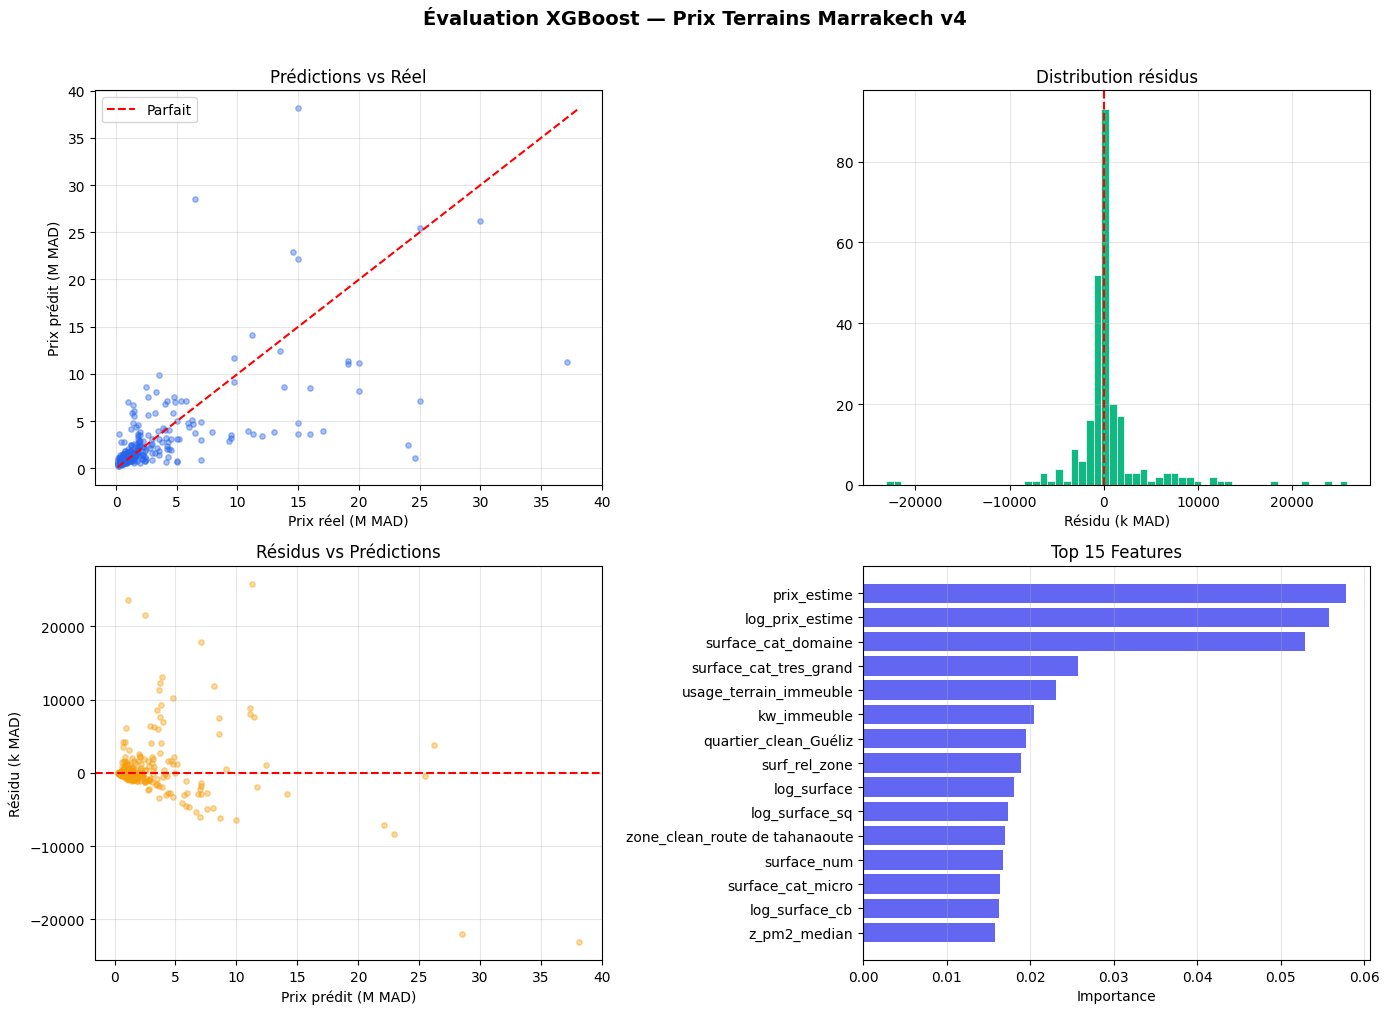

In [ ]:
residuals = y_true_mad - y_pred_mad
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Évaluation XGBoost — Prix Terrains Marrakech v4", fontsize=14, fontweight="bold", y=1.01)

ax = axes[0,0]
ax.scatter(y_true_mad/1e6, y_pred_mad/1e6, alpha=0.4, s=15, color="#2563EB")
lims=[min(y_true_mad.min(),y_pred_mad.min())/1e6, max(y_true_mad.max(),y_pred_mad.max())/1e6]
ax.plot(lims,lims,"r--",lw=1.5,label="Parfait"); ax.legend()
ax.set_xlabel("Prix réel (M MAD)"); ax.set_ylabel("Prix prédit (M MAD)")
ax.set_title("Prédictions vs Réel"); ax.grid(True,alpha=0.3)

ax = axes[0,1]
ax.hist(residuals/1e3,bins=60,color="#10B981",edgecolor="white",lw=0.5)
ax.axvline(0,color="red",ls="--",lw=1.5)
ax.set_xlabel("Résidu (k MAD)"); ax.set_title("Distribution résidus"); ax.grid(True,alpha=0.3)

ax = axes[1,0]
ax.scatter(y_pred_mad/1e6,residuals/1e3,alpha=0.4,s=15,color="#F59E0B")
ax.axhline(0,color="red",ls="--",lw=1.5)
ax.set_xlabel("Prix prédit (M MAD)"); ax.set_ylabel("Résidu (k MAD)")
ax.set_title("Résidus vs Prédictions"); ax.grid(True,alpha=0.3)

ax = axes[1,1]
pre = pipeline_final.named_steps["pre"]; mdl = pipeline_final.named_steps["model"]
try:
    fn = (list(pre.transformers_[0][2])+list(pre.transformers_[1][2])+
          list(pre.transformers_[2][1].get_feature_names_out(cat_cols)))
except:
    fn = [f"f{i}" for i in range(mdl.n_features_in_)]
imp=mdl.feature_importances_; top=min(15,len(fn)); idx=np.argsort(imp)[-top:]
ax.barh([fn[i] for i in idx],imp[idx],color="#6366F1")
ax.set_xlabel("Importance"); ax.set_title(f"Top {top} Features"); ax.grid(True,alpha=0.3,axis="x")

plt.tight_layout()
plt.savefig("terrain_model_evaluation.png",dpi=150,bbox_inches="tight"); plt.show()


## 9. Analyse erreurs

In [10]:
erreur_pct = np.abs((y_true_mad - y_pred_mad) / y_true_mad) * 100
df_err = X_test[ALL_FEATURES].copy()
df_err["prix_reel"]=y_true_mad; df_err["prix_predit"]=y_pred_mad; df_err["erreur_pct"]=erreur_pct
df_err["surface"] = df.loc[X_test.index,"surface_num"].values

print("=== MAPE par quartier ===")
print(df_err.groupby("quartier_clean")["erreur_pct"]
      .agg(["mean","count"]).sort_values("mean",ascending=False).round(1))

print("\n=== MAPE par usage_terrain ===")
print(df_err.groupby("usage_terrain")["erreur_pct"]
      .agg(["mean","count"]).sort_values("mean",ascending=False).round(1))

df_err["tranche"] = pd.cut(df_err["surface"],
    bins=[0,300,1000,5000,20000,999999],
    labels=["<300m²","300-1k","1k-5k","5k-20k",">20k"])
print("\n=== MAPE par tranche de surface ===")
print(df_err.groupby("tranche",observed=True)["erreur_pct"]
      .agg(["mean","count","median"]).round(1))

print("\n=== Précision par seuil ===")
for s in [10,20,30,50]:
    print(f"  Erreur <= {s:2d}% : {(erreur_pct<=s).mean()*100:.1f}% des cas")


=== MAPE par quartier ===
                      mean  count
quartier_clean                   
Guéliz               303.0      6
Route d'Amizmiz      193.1      2
Route de Casablanca   78.6     29
Autre                 76.8    137
Route de Fès          71.2     30
Route d'Ourika        53.8     37
Palmeraie             38.3      5
Targa                 24.3      7
Agdal                 21.9      5

=== MAPE par usage_terrain ===
               mean  count
usage_terrain             
autre          80.3    186
agricole       76.3     31
industriel     67.2      6
golf           62.7     19
immeuble       43.8     16

=== MAPE par tranche de surface ===
          mean  count  median
tranche                      
<300m²    72.9     69    31.6
300-1k    44.3     50    36.2
1k-5k    122.3     50    71.4
5k-20k    60.3     60    53.3
>20k      90.3     29    45.4

=== Précision par seuil ===
  Erreur <= 10% : 11.6% des cas
  Erreur <= 20% : 25.6% des cas
  Erreur <= 30% : 35.3% des cas
  Erreu

## 10. Sauvegarde

In [11]:
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
os.makedirs(os.path.dirname(CLEAN_PATH), exist_ok=True)

# Sauvegarder pipeline + infos nécessaires pour predict_price
encode_stats = {
    "z_pm2_med"  : df.groupby("zone_clean")["pm2"].median().to_dict(),
    "z_pm2_mean" : df.groupby("zone_clean")["pm2"].mean().to_dict(),
    "q_pm2_med"  : df.groupby("quartier_clean")["pm2"].median().to_dict(),
    "z_surf_med" : df.groupby("zone_clean")["surface_num"].median().to_dict(),
    "fp2"        : float(df["pm2"].median()),
    "fs"         : float(df["surface_num"].median()),
    "all_features": ALL_FEATURES,
    "num_cols"   : num_cols,
    "bin_cols"   : bin_cols,
    "cat_cols"   : cat_cols,
}
joblib.dump({"pipeline": pipeline_final, "stats": encode_stats}, MODEL_PATH)
print(f"✅ Modèle sauvegardé       → {MODEL_PATH}")

metadata = {
    "date"           : datetime.now().strftime("%Y-%m-%d"),
    "version"        : "v4_optuna",
    "modele"         : "XGBRegressor",
    "type_bien"      : "terrain_vente",
    "target"         : "log(prix_total)",
    "n_lignes_train" : len(X_train),
    "n_lignes_test"  : len(X_test),
    "n_features"     : len(ALL_FEATURES),
    "n_zones"        : int(df["zone_clean"].nunique()),
    "sources"        : df["source_clean"].value_counts().to_dict() if "source_clean" in df.columns else {},
    "features_cles"  : ["log_surface","z_pm2_median","log_prix_estime","terrain_quality","kw_facade","kw_immeuble","kw_agricole"],
    "metriques_test" : {
        "R2"   : round(metrics_final["R²"],4),
        "MAE"  : round(metrics_final["MAE (MAD)"],0),
        "RMSE" : round(metrics_final["RMSE (MAD)"],0),
        "MAPE" : round(metrics_final["MAPE (%)"],2),
    },
    "hyperparametres": study.best_params,
    "affichage_site" : "Fourchette ±40% obligatoire pour les terrains",
    "formule"        : "prix_min = prix_estime × 0.60 | prix_max = prix_estime × 1.60",
}
with open(META_PATH,"w",encoding="utf-8") as f:
    json.dump(metadata,f,ensure_ascii=False,indent=2)
print(f"✅ Métadonnées sauvegardées → {META_PATH}")

df.to_csv(CLEAN_PATH, index=False)
print(f"✅ Dataset sauvegardé      → {CLEAN_PATH}")

print("\n"+"═"*55)
print("  RÉSUMÉ FINAL — TERRAIN VENTE v4")
print("═"*55)
print(f"  Données          : {len(df):,} terrains | {df['zone_clean'].nunique()} zones")
print(f"  Features         : {len(ALL_FEATURES)}")
print(f"  R² (test)        : {metrics_final['R²']:.4f}")
print(f"  MAE (test)       : {metrics_final['MAE (MAD)']:,.0f} MAD")
print(f"  MAPE (test)      : {metrics_final['MAPE (%)']:.2f} %")
print(f"  CV R² Optuna     : {study.best_value:.4f}")
print("═"*55)
print(f"\n  Appartements : R²=0.73, MAPE=19% ✅  Prix fixe")
print(f"  Villas       : R²=0.65, MAPE=26% ⚠️   Fourchette ±30%")
print(f"  Terrains     : R²={metrics_final['R²']:.2f}, MAPE={metrics_final['MAPE (%)']:.0f}% ⚠️   Fourchette ±40%")


✅ Modèle sauvegardé       → ../../model_training/models/xgb_terrain_vente.pkl
✅ Métadonnées sauvegardées → ../../model_training/models/xgb_terrain_vente_metadata.json
✅ Dataset sauvegardé      → ../../data/cleaned_data/vente/terrain_vente_final.csv

═══════════════════════════════════════════════════════
  RÉSUMÉ FINAL — TERRAIN VENTE v4
═══════════════════════════════════════════════════════
  Données          : 1,286 terrains | 38 zones
  Features         : 39
  R² (test)        : 0.3351
  MAE (test)       : 2,100,269 MAD
  MAPE (test)      : 75.96 %
  CV R² Optuna     : 0.6131
═══════════════════════════════════════════════════════

  Appartements : R²=0.73, MAPE=19% ✅  Prix fixe
  Villas       : R²=0.65, MAPE=26% ⚠️   Fourchette ±30%
  Terrains     : R²=0.34, MAPE=76% ⚠️   Fourchette ±40%


## 11. Fonction de prédiction

In [12]:
def predict_terrain(pipeline_saved, terrain: dict) -> dict:
    """
    Prédit le prix d'un terrain avec fourchette ±40%.
    
    terrain dict doit contenir au minimum :
        surface_num, zone_clean, quartier_clean, usage_terrain
    """
    stats     = pipeline_saved["stats"]
    pipeline  = pipeline_saved["pipeline"]
    
    t = terrain.copy()
    t["log_surface"]    = np.log(t["surface_num"])
    t["log_surface_sq"] = t["log_surface"]**2
    t["log_surface_cb"] = t["log_surface"]**3
    
    zm = stats["z_pm2_med"].get(t.get("zone_clean","autre_zone"), stats["fp2"])
    qm = stats["q_pm2_med"].get(t.get("quartier_clean","Autre"),  stats["fp2"])
    sm = stats["z_surf_med"].get(t.get("zone_clean","autre_zone"), stats["fs"])
    
    t["z_pm2_median"]    = zm
    t["z_pm2_mean"]      = stats["z_pm2_mean"].get(t.get("zone_clean","autre_zone"), stats["fp2"])
    t["q_pm2_median"]    = qm
    t["prix_estime"]     = t["surface_num"] * zm
    t["log_prix_estime"] = np.log(max(t["prix_estime"], 1))
    t["log_surf_x_pm2"]  = t["log_surface"] * zm / 1e3
    t["surf_rel_zone"]   = t["surface_num"] / sm
    t["te_log_pm2_zone"] = np.log(max(zm, 1))
    
    df_in = pd.DataFrame([t])
    all_f = stats["all_features"]
    for c in all_f:
        if c not in df_in.columns:
            df_in[c] = 0
    
    prix_pred = np.exp(pipeline.predict(df_in[all_f])[0])
    prix_min  = prix_pred * 0.60
    prix_max  = prix_pred * 1.60
    pm2_pred  = prix_pred / t["surface_num"]
    
    print(f"💰 Prix estimé   : {prix_pred:,.0f} MAD ({prix_pred/10.8:,.0f} EUR)")
    print(f"   Fourchette    : {prix_min:,.0f} – {prix_max:,.0f} MAD")
    print(f"   Prix/m²       : {pm2_pred:,.0f} MAD/m²")
    print(f"   Surface       : {t['surface_num']:,.0f} m²")
    return {"prix_estime": prix_pred, "prix_min": prix_min, "prix_max": prix_max, "pm2": pm2_pred}

# Exemple
saved = joblib.load(MODEL_PATH)
terrain_exemple = {
    "surface_num"     : 1500,
    "zone_clean"      : "targa",
    "quartier_clean"  : "Targa",
    "usage_terrain"   : "autre",
    "statut_titre"    : "titre_foncier",
    "source_clean"    : "avito",
    "surface_cat"     : "moyen",
    "kw_immeuble":0,"kw_agricole":0,"kw_golf":0,"kw_villa_zone":0,
    "kw_resid":1,"kw_facade":0,"kw_projet":0,"kw_constructible":1,
    "kw_plat":1,"kw_urgent":0,"kw_viabilise":0,"kw_industriel":0,
    "kw_tf":1,"kw_melk":0,"terrain_quality":3,
    "piscine":0,"parking":0,"jardin":0,"securite":0,"vue":0,"neuf":0,
}
result = predict_terrain(saved, terrain_exemple)


💰 Prix estimé   : 4,176,881 MAD (386,748 EUR)
   Fourchette    : 2,506,128 – 6,683,010 MAD
   Prix/m²       : 2,785 MAD/m²
   Surface       : 1,500 m²
